# <font color = Cornflowerblue>Pytorch learning</font>

## <font color="Cornflowerblue">一、张量的基本操作</font>
1. 张量创建方法
    - `torch.Tensor()`
    - `torch.zeros()/ones()/empty()`
    - `torch.randn()/randint()/rand()`
2. 张量的方法和属性
   - 张量中只有1个元素的时候，`tensor.item()`
   - 转换为numpy数组：`tensor.numpy()`
   - 获取形状
        1. `tensor.size()`
        2. `tensor.size(idm)` #获取对应维度的形状
   - 改变形状：`tensor.view((shape))`
   - 获取阶数：`tensor.dim()`
   - 最大值、最小值等和numpy基本一致
   - 转置：
        1. 二维：`tensor.t() / tensor.transpose(0,1)`
        2. 高维：`tensor.transpose(1,2) / tensor.permutate(0,2,1)`
   - 取值：和numpy一致
   

In [2]:
torch.tensor([1, 2], dtype=torch.double)

tensor([1., 2.], dtype=torch.float64)

3. 数据类型
   - 指定数据类型：用dtype去声明,例如：`dtype=torch.float16/32/64` `torch.int16/32/64`
   - 获取数据类型：`.dtype`
   - 修改数据类型：`tensor.float()/.double()/.int()` 

In [3]:
torch.tensor(np.arange(12).reshape(2,2,3)).transpose(0,1)
# transpose就是从对应的视角去看就行了，0，1就是从上往下看

tensor([[[ 0,  1,  2],
         [ 6,  7,  8]],

        [[ 3,  4,  5],
         [ 9, 10, 11]]])

4. _下划线的方法直接进行修改
5. CUDA中的tensor
   - `device = torch.device("cuda" if torch.cuda.is_available() else "cpu")`
   - `torch.zeros([2,3], device = device)`
   - `a= torch.zeros([2,3]),  a.to(device)`

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### 进行梯度计算
1. 创建：
   - `tensor(data, requires_grad = True`
   - tensor 后续会被计算梯度
   - tensor所有的操作都会被记录在grad_fn中 
2. `with torch.no_grad()`:其中的操作不会被追踪，在推理阶段和评估模型阶段，可以用来提高效率
3. 调用`z.backward()`来计算对于所有变量的梯度，`x.grad`来打印对应梯度
4. 每次在计算梯度之前，需要将原本的变量的梯度置为0，否则梯度会进行累加。`.grad.zero_()`

### 注意
1. `tensor.data`
   - 当 `requires_grad` 为true时，`tensor.data`仅仅只是获取tensor中的数据
   - 改变data中的值，原张量也会跟着改变
2. `tensor.numpy()`
   - `requires_grad=true`不能直进行转换，需要使用`tensor.detach().numpy`  来进行深拷贝


Epoch 0: loss = 4.139342308044434
Epoch 50: loss = 0.04093361645936966
Epoch 100: loss = 0.010511630214750767
Epoch 150: loss = 0.002699360717087984
Epoch 200: loss = 0.0006931839161552489
Epoch 250: loss = 0.0001780123420758173
Epoch 300: loss = 4.5715292799286544e-05
Epoch 350: loss = 1.174072804133175e-05
Epoch 400: loss = 3.0148180485412013e-06


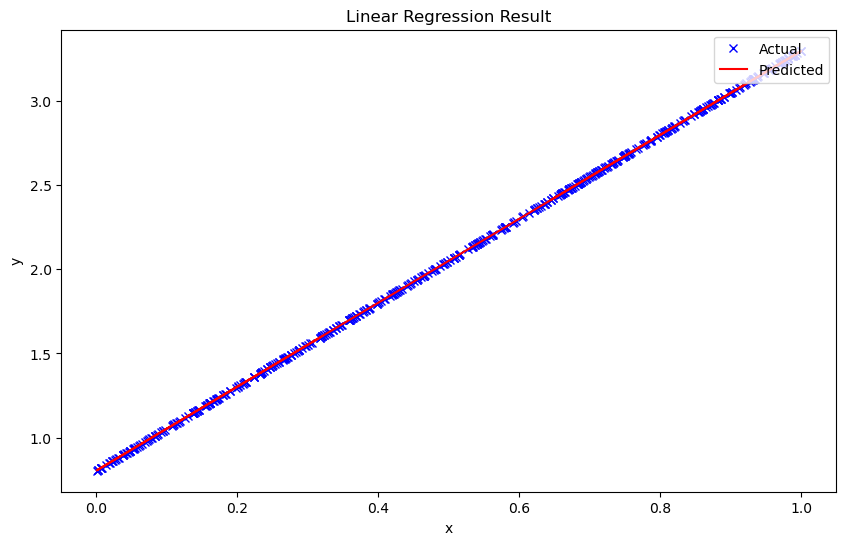

In [5]:
# 实现简单的线性回归

# 1.准备数据
x_test = torch.rand([500,1])
y_test = 2.5*x_test + 0.8

# 2. 通过模型计算y_predict
w = torch.rand([1, 1], requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# 4.通过循环，反向传播
learning_rate = 0.1
tolerance = 1e-6
for epoch in range(700):
    #计算预估值和损失
    y_predict = w * x_test + b
    loss = (y_predict - y_test).pow(2).mean()

    #进行反向传播的计算
    loss.backward()

    #更新参数
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    
    #将梯度清零
    w.grad.zero_()
    b.grad.zero_()

    #打印损失值
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: loss = {loss.item()}')
    
    #判断是否已经收敛
    if abs(loss.item()) < tolerance :
        break

# 画出对应图像
plt.figure(figsize=(10,6))
plt.plot(x_test.numpy(), y_test.numpy() , 'bx', label = 'Actual')
plt.plot(x_test.numpy(), y_predict.detach().numpy(),'r-', label = 'Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc = 'upper right')
plt.title('Linear Regression Result')
plt.show()

## <font color = Cornflowerblue>二、调用pytorch的api来实现线性回归</font>

### 2.1 nn.Module

nn.Module 提供了一些关键功能，这些功能在构建和训练神经网络时非常重要：

1. 参数管理：nn.Module 会自动注册所有子模块和参数，这样你可以方便地管理和优化模型的参数。例如，model.parameters() 会返回模型中所有参数的迭代器。
2. 前向传播：你可以通过定义 forward 方法来实现模型的前向传播逻辑。nn.Module 提供了一个统一的接口来调用前向传播。
3. 模型嵌套：你可以将多个子模块组合成一个更复杂的模型。nn.Module 会自动管理这些子模块。
4. 模型保存和加载：nn.Module 提供了 state_dict 方法来保存和加载模型的参数，这对于模型的持久化和分发非常有用。
5. 设备管理：nn.Module 提供了 to 方法，可以方便地将模型移动到指定的设备（如 GPU）。

### 2.2 optimizer

优化器类，可以理解为torch为我们封装的来进行参数更新的方法，比如常见的随机梯度递降（SGD）

优化器类是由`torch.optim`提供的，例如：
1. `torch.optim.SGD(model.parameters(), learning_rate)`
2. 一般使用optim有以下几个步骤：
```
optimizer = optim.SGD(parameters, lr) #实例化
optimizer.zero_grad()  #将梯度置为零
loss.backward() #计算梯度
optimizer.step() #更新参数值
```
3. 其中的损失函数可以自行定义，也可以用nn中提供的,如`nn.MSELoss()`

### 2.3 用api来实现linear regression

0.0020136928651481867 [Parameter containing:
tensor([[2.3503]], requires_grad=True), Parameter containing:
tensor([0.8778], requires_grad=True)]


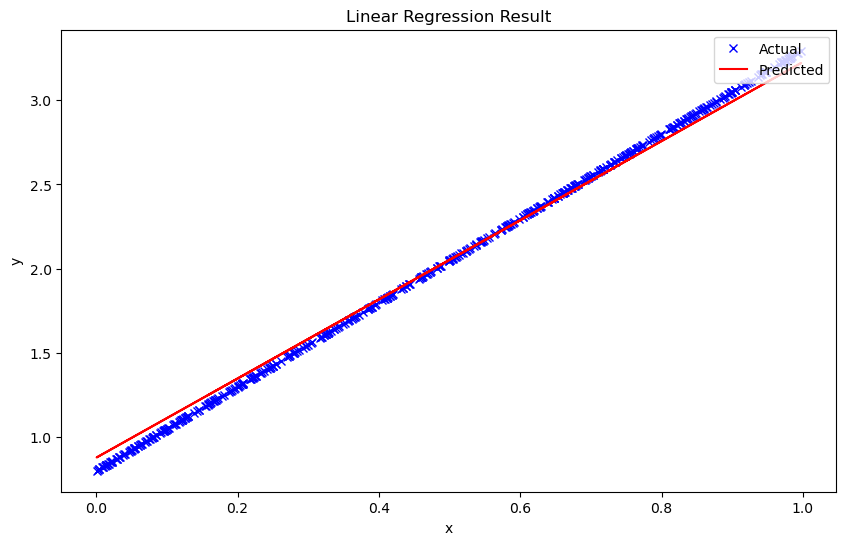

In [6]:
import torch.nn as nn
import torch.optim as optim
lr = 0.1
tolerant = 1e-6
x_test = torch.rand([500,1])
y_test = 2.5*x_test + 0.8

class MyLinear(nn.Module):
    def __init__(self):
        super(MyLinear, self).__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, input):
        out = self.linear(input)
        return out

my_linear = MyLinear()

optimizer = optim.SGD(my_linear.parameters(), lr)

criterion = nn.MSELoss()

for i in range(200) :
    y_predict = my_linear(x_test)
    loss = criterion(y_predict, y_test)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if abs(loss.item()) < tolerant:
        break

print(loss.item(), list(my_linear.parameters()))
plt.figure(figsize=(10,6))
plt.plot(x_test.numpy(), y_test.numpy() , 'bx', label = 'Actual')
plt.plot(x_test.numpy(), y_predict.detach().numpy(),'r-', label = 'Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc = 'upper right')
plt.title('Linear Regression Result')
plt.show()


### 注意
1. `model.train(True)`表示将模型设置为训练模式
2. `model.eval()`表示设置模型为评估模式
   - 此时dropout层不会执行
   - Batchnorm使用整个训练集的均值和方差进行归一化

### 2.4 在GPU上运行代码
 1. 判断`torch.cuda.is_available()`
 2. 将模型参数和input数据转换为cuda的支持类型
    - `model.to(device)`
    - `x_test/y_test.to(device)` 
  3. 在GPU上运行的结果也为cuda的数据类型，需要转换为numpy或者cpu的tensor类型   
     - `predict = predict.cpu().detach().numpy()`

### 2.5 常见的优化算法介绍
1. Batch gradient descent
2. Stochastic gradient descent
3. Mini-batch gradient descent
4. Momentum
   $$v_t = \beta v_{t-1} + (1-\beta)\nabla J(\theta_t)$$ 
   $$ \theta_{t+1} = \theta_{t} - \alpha v_t$$
5. AdaGrad
   - 是一种自适应学习率优化算法，它根据参数的历史梯度信息来调整每个参数的学习率。AdaGrad的主要优点是能够处理稀疏数据和具有不同尺度的特征
   - 更新规则：
  $$G_t = G_{t-1} + \nabla J(\theta_t)^2$$
  $$\theta_{t+1} = \theta_{t} - \frac{\alpha}{\sqrt{G_t} + \epsilon} g_t$$
6. RMSProp（Root Mean Square Propagation）是一种自适应学习率优化算法，它通过对梯度平方的移动平均来调整每个参数的学习率。RMSprop 旨在解决 AdaGrad 中学习率衰减过快的问题，使得优化过程更加稳定和高效。
   - 更新规则： 
  $$ E[g^2]_t = \beta E[g^2]_{t-1} + (1 - \beta) \nabla J(\theta_t) $$
  $$ \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{E[g^2]_t} + \epsilon} g_t $$
7. Adam
   - 将Momentum和RMSprop算法结合起来使用的一种算法，一方面能够防止梯度的摆幅过大，同时还能加快收敛速度。
   - 更新规则 
\begin{align*}
    m_t &= \beta_1 m_{t-1} + (1-\beta_1) \nabla J(\theta_{t}) \\
    v_t &= \beta_2 v_{t-1} + (1-\beta_2) \nabla J(\theta_{t})^2 \\
    \hat{m}_t&= \frac{m_t}{1 - \beta_1^t} \\
    \hat{v}_t&= \frac{v_t}{1- \beta_2^t} \\
    \theta_{t+1} &= \theta_{t} - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t \\
\end{align*}
   - 其中第三、四步是在进行偏差较正，是为了防止在初始阶段的动量项和梯度平方的移动项过小，从而提高优化过程的稳定性和收敛速度。

## <font color = Cornflowerblue>三、Pytorch中的数据加载 </font>
### 3.1 数据集类（Dataset）


在pytorch中提供了torch.utils.data.Dataset, 继承这个基类， 我们能够非常快速地对数据进行加载。其源码如下：
```python
import torch
from torch.utils.data import Dataset

class Dataset(object):
    """An abstract class representing a Dataset.

    All datasets that represent a map from keys to data samples should subclass it.
    All subclasses should override `__len__`, that provides the size of the dataset,
    and `__getitem__`, supporting integer indexing in range from 0 to len(self) exclusive.
    """

    def __getitem__(self, index):
        raise NotImplementedError

    def __len__(self):
        raise NotImplementedError

    def __add__(self, other):
        return ConcatDataset([self, other])


我们只需要继承这个基类就可以实现对数据的加载。

### 3.2 数据加载器类（Dataloader）


Dataloader是Pytorch中用于加载数据的工具，它可以将数据集分成小批量(mini-batch)，并提供多线程数据加载、数据打乱等功能。下面是一个例子：  
`dataloader = Dataloader(dataset, batch_size=10, shuffle=True, num_workers=4)`
- `dataset`: 要加载的数据集
- `batch_size`: 每个小批量的样本数量
- `shuffle`：是否在每个 epoch 开始时打乱数据。
- `num_workers`：用于数据加载的子进程数量。设置为 0 表示数据将在主进程中加载。
- `drop_last`：如果数据集大小不能被批量大小整除，是否丢弃最后一个不完整的小批量。

### 3.3 Transform的用法

`Transform`用于对数据进行预处理和增强,一般用于创建Dataset的过程。    
你可以自己去定义一个transform，要实现`__init__`方法和`__call__`方法，如下所示表示对数据集乘上一个常数：
```python
class MyTransform:
    def __init__(self, factor):
        self.factor = factor
    
    def __call__(self, sample):
        return sample * self.factor
```

在torch中，torchvision.transforms提供了许多常见的图像变换方法，以下是一些常见的transforms方法及其用途：
1. transforms.Compose:将多个变换组合在一起
```python
transform.Compose([
    transform.Resize((128,128)),
    transform.ToTensor()
])
```
2. transforms.ToTensor:
    - 将图像数据从PIL图像或numpy数组转换为Pytorch张量
    - 将图像的像素归一化到[0,1]的范围
3. tensorform.Normalize(mean, std):
    - 给定均值和标准差，就可以将数据进行标准差
    - 以下是计算mean和std的简单实现：
```python
# 计算均值和标准差
for data in dataloader:
    images, _ = data
    batch_samples = images.size(0)  # batch size (current batch)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    nb_samples += batch_samples
mean /= nb_samples
std /= nb_samples
```


### 3.4 实现手写数字识别

分为三步进行：
1. 数据集的准备
   - 创建transform
   - 创建Dataset 
   - 构建Dataloader 
2. 模型的构建
   - nn.Module 
3. 模型的训练
   - 导入数据 
   - 设置损失函数
   - 设置优化器

### 3.5 模型的保存与加载
1. 模型的保存：
```python
torch.save(sample.state_dict(), 'model/sample.pt') #保存模型参数
torch.save(optimizer.state_dict(), 'model/optimizer.pt') #保存优化器参数
```
2. 模型的加载
```python
sample.load_state_dict(torch.load('model/sample.pt')) 
optimizer.load_state_dict(torch.load('model/optimizer.pt'))
``` 

### 3.6 模型的评估
1. 将模型转换为评估模式
2. 加载数据集，数据集的`train = False`
3. 在`torch.no_grad()`条件下进行测试，损失函数和训练一致，不过不需要更新数据，只需要对预测结果进行处理